# Evaluate Model Performance

## Import Evaluator Module

In [1]:
from util.Evaluator import Evaluator

## Load Model

In [2]:
model_dir = "GAGEii-ALL_Gauges_Filtered_Periodically_GMM_eslstm_0903_052313" # Specify the model name
epoch_num = 19 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation
eval_list = "basin_list/complete_basin_list.txt"

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      eval_list=eval_list,
                      skip_sim=True,
                      test_start_date="01/01/2013",
                      test_end_date="31/12/2023",
                      apply_transformation=False)

  0%|          | 0/975 [00:00<?, ?it/s]


ValueError: All arrays must be of the same length

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neuralhydrology.nh_run import eval_run
import pickle
from pathlib import Path
import os
from tqdm import tqdm


with open(Path("runs") / model_dir / "test" / "model_epoch019" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)

In [17]:
csv_dir = "metadata/csv_filtered"
basin_id = "04245000"
test_start_date="01/01/2013"
test_end_date="31/12/2023"
target_var = "discharge"

csv_file_path = Path(csv_dir) / f"{basin_id}.csv"
df = pd.read_csv(csv_file_path, index_col='date', parse_dates=True)
df = df.loc[test_start_date:test_end_date, [target_var]]

In [28]:
len(sim.flatten())

40170

In [32]:
sim.shape

(4017, 1, 10)

In [30]:
sim.flatten()

array([3.2197714, 4.268629 , 2.1733627, ..., 4.588747 , 4.472522 ,
       4.342991 ], dtype=float32)

In [29]:
obs = df[target_var].values
sim = results[basin_id]["1D"]["xr"]['discharge_sim'].values
dates = results[basin_id]["1D"]["xr"]['discharge_sim']['date'].values

obs_sim_df = pd.DataFrame({
    'date': dates,
    'observed': obs.flatten(),
    'simulated': sim
    })
# drop rows with missing values
obs_sim_df = obs_sim_df.dropna()

observed_values = obs_sim_df['observed'].values
simulated_values = obs_sim_df['simulated'].values
dates = obs_sim_df['date']

ValueError: Per-column arrays must each be 1-dimensional

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming `results` is already loaded with subbasin data.

# Extract subbasin keys
subbasin_keys = list(results.keys())

# Initialize lists to store NSE values and subbasin IDs
nse_values = []
subbasin_ids = []

# Loop through each subbasin and collect NSE values
for key in subbasin_keys:
    
    if 'NSE' not in results[key]['1D']:
        print(f"Skipping {key} as it does not have 1D results.")
        continue
    
    nse = results[key]['1D']['NSE']
    nse_values.append(nse)
    subbasin_ids.append(key)

# Convert to a DataFrame for easier manipulation and visualization
nse_df = pd.DataFrame({'Subbasin': subbasin_ids, 'NSE': nse_values})

# Statistical Summary
summary_stats = nse_df['NSE'].describe()

Skipping 02AA001 as it does not have 1D results.
Skipping 02AA002 as it does not have 1D results.
Skipping 02AB001 as it does not have 1D results.
Skipping 02AB002 as it does not have 1D results.
Skipping 02AB004 as it does not have 1D results.
Skipping 02AB005 as it does not have 1D results.
Skipping 02AB007 as it does not have 1D results.
Skipping 02AB009 as it does not have 1D results.
Skipping 02AB010 as it does not have 1D results.
Skipping 02AB011 as it does not have 1D results.
Skipping 02AB012 as it does not have 1D results.
Skipping 02AB013 as it does not have 1D results.
Skipping 02AB015 as it does not have 1D results.
Skipping 02AB016 as it does not have 1D results.
Skipping 02AD011 as it does not have 1D results.
Skipping 02BA002 as it does not have 1D results.
Skipping 02BB002 as it does not have 1D results.
Skipping 02BC002 as it does not have 1D results.
Skipping 02BC003 as it does not have 1D results.
Skipping 02BC005 as it does not have 1D results.
Skipping 02BD001 as 

In [10]:
len(results["02AA001"]["1D"]["xr"]['discharge_sim'])

4017

In [20]:
detected = []

for key in subbasin_keys:
    if len(results[key]["1D"]["xr"]['discharge_sim']) != 4017:
        detected.append(key)
        
detected

[]

## Plot the validation curve to possibly identify overfitting

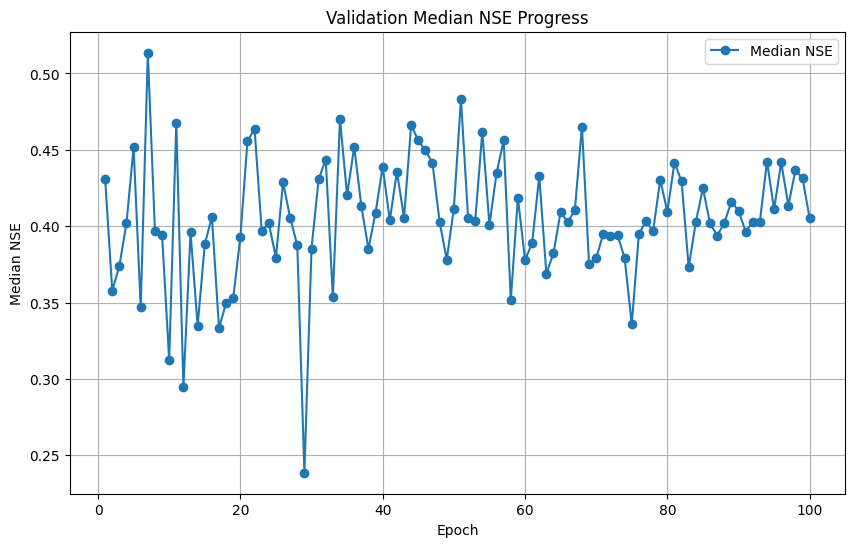

In [21]:
evaluator.plot_validation("Median")

## Evaluation Results

In [22]:
print(evaluator)

Summary Statistic: 
count    137.000000
mean      -3.255061
std       13.080074
min      -92.780883
25%       -0.759337
50%        0.266924
75%        0.606344
max        0.845769
Name: NSE, dtype: float64

Performance Summary: 
Performance
Negative          105
Good               41
Unsatisfactory     36
Excellent          13
Name: count, dtype: int64

evaluate GAGEii-ALL_Gauges_Filtered_Regionally_Separate_Recent_0803_171549 epoch 100


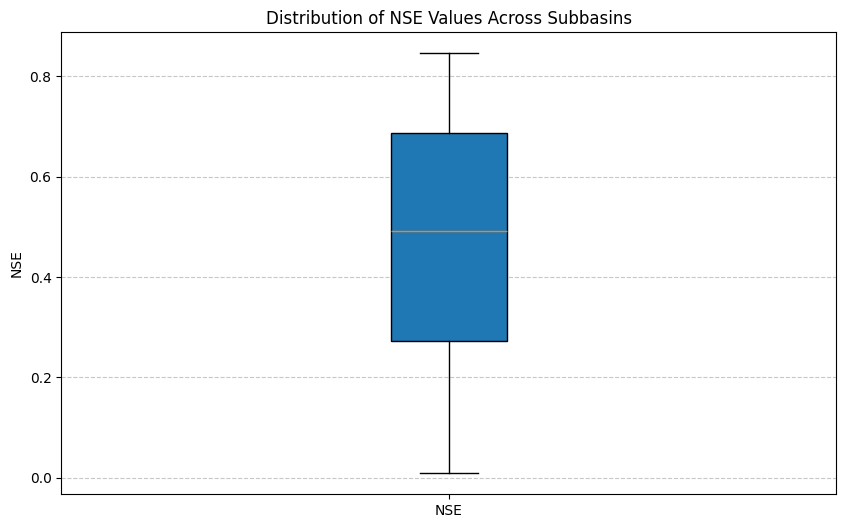

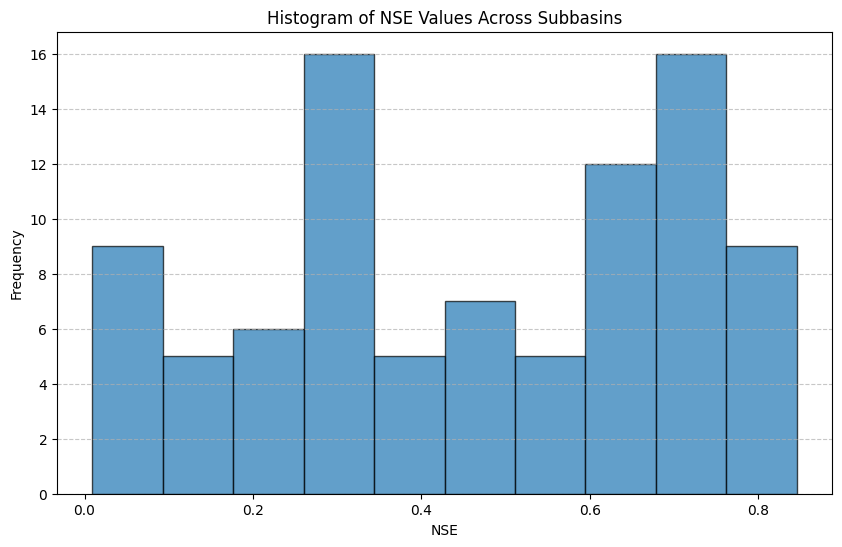

In [25]:
evaluator.plot_nse_distribution()

## Scatterplot of NSE vs Coverage

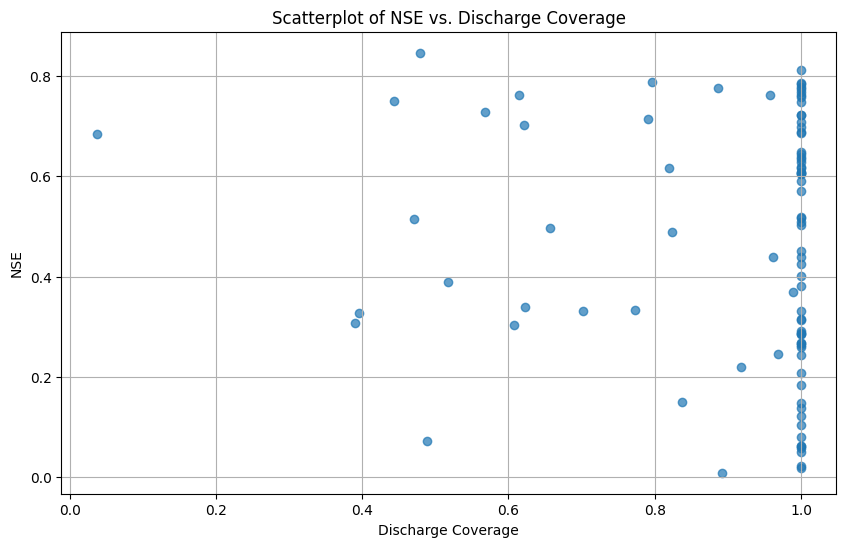

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

nse_df = evaluator.get_nse()
nse_df_filtered = nse_df[nse_df["NSE"] > 0]
coverage_df = pd.read_csv("metadata/coverage.csv")

# Merge the two dataframes on 'basin_id'
merged_df = pd.merge(nse_df_filtered, coverage_df, on="basin_id", how="inner")

# Create the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["discharge_coverage"], merged_df["NSE"], alpha=0.7)
plt.xlabel("Discharge Coverage")
plt.ylabel("NSE")
plt.title("Scatterplot of NSE vs. Discharge Coverage")
plt.grid(True)
plt.show()

In [24]:
nse_df_filtered.describe()

,NSE
count,90.000000
mean,0.460812
std,0.244108
min,0.009208
25%,0.271941
50%,0.492524
75%,0.687796
max,0.845769
